## Crime rate and safty Prediction
## Project - Data Science and AI
## Name - Livashini
## Date - 23-06-2026

In [24]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import f_oneway
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error,precision_recall_curve,average_precision_score, f1_score, precision_score, accuracy_score, recall_score,classification_report, confusion_matrix, ConfusionMatrixDisplay, auc, roc_curve, roc_auc_score
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression,LinearRegression,Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,StratifiedKFold,cross_validate
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,ExtraTreesClassifier,
    GradientBoostingClassifier, GradientBoostingRegressor,AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [25]:
os.chdir("C:\\Users\\livap\\OneDrive\\Python\\DSAIProject\\Classification")
os.getcwd()

'C:\\Users\\livap\\OneDrive\\Python\\DSAIProject\\Classification'

In [26]:
outputfolder = "C:\\Users\\livap\\OneDrive\\Python\\DSAIProject\\Classification\\Output"

In [27]:
df = pd.read_csv("C:\\Users\\livap\\OneDrive\\Python\\DSAIProject\\Classification\\Data\\crime_rate_safety_analysis.csv")
df

,incident_id,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,CRM0000001,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,...,2,46,No,No,No,No Coverage,Poorly Lit,3,62.8,No
1,CRM0000002,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,...,2,115,No,Yes,No,Partial Coverage,Partially Lit,1,50.7,No
2,CRM0000003,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,...,1,56,Yes,No,No,No Coverage,Well Lit,0,61.3,Yes
3,CRM0000004,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,...,4,44,Yes,Yes,No,Partial Coverage,Partially Lit,6,51.7,Yes
4,CRM0000005,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,...,5,111,No,Unknown,Yes,Partial Coverage,Partially Lit,2,52.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CRM0009996,2024,11,Thursday,Winter,Morning (6am-12pm),Turkey,Suburban,327,Burglary,...,3,27,No,Yes,No,Partial Coverage,Well Lit,5,75.6,No
9996,CRM0009997,2024,4,Tuesday,Spring,Afternoon (12pm-6pm),Germany,Urban,1136,Burglary,...,5,41,No,No,No,Partial Coverage,Partially Lit,0,61.4,No
9997,CRM0009998,2024,11,Tuesday,Summer,Evening (6pm-10pm),France,Suburban,436,Assault,...,3,30,Unknown,No,Yes,Partial Coverage,Poorly Lit,1,65.1,Yes
9998,CRM0009999,2022,1,Friday,Summer,Evening (6pm-10pm),USA,Rural,169,Cybercrime,...,1,27,Unknown,No,No,Partial Coverage,Well Lit,2,77.5,No


In [28]:
print(f"Dataset Loaded! Shape: {df.shape}")

Dataset Loaded! Shape: (10000, 32)


In [29]:
# Basic Inspection
print("\nFirst 5 Rows:")
df.head()



First 5 Rows:


,incident_id,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,CRM0000001,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,...,2,46,No,No,No,No Coverage,Poorly Lit,3,62.8,No
1,CRM0000002,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,...,2,115,No,Yes,No,Partial Coverage,Partially Lit,1,50.7,No
2,CRM0000003,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,...,1,56,Yes,No,No,No Coverage,Well Lit,0,61.3,Yes
3,CRM0000004,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,...,4,44,Yes,Yes,No,Partial Coverage,Partially Lit,6,51.7,Yes
4,CRM0000005,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,...,5,111,No,Unknown,Yes,Partial Coverage,Partially Lit,2,52.0,No


In [30]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   incident_id                    10000 non-null  object 
 1   year                           10000 non-null  int64  
 2   month                          10000 non-null  int64  
 3   day_of_week                    10000 non-null  object 
 4   season                         10000 non-null  object 
 5   time_of_day                    10000 non-null  object 
 6   country                        10000 non-null  object 
 7   area_type                      10000 non-null  object 
 8   population_density_per_sqkm    10000 non-null  int64  
 9   crime_type                     10000 non-null  object 
 10  crime_severity_score           10000 non-null  float64
 11  victim_count                   10000 non-null  int64  
 12  victim_gender            

In [31]:
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
incident_id                         0
year                                0
month                               0
day_of_week                         0
season                              0
time_of_day                         0
country                             0
area_type                           0
population_density_per_sqkm         0
crime_type                          0
crime_severity_score                0
victim_count                        0
victim_gender                       0
victim_age_group                    0
injuries_reported                   0
fatalities                          0
financial_loss_usd                  0
weapon_used                      3572
suspect_status                      0
case_status                         0
reporting_method                    0
response_time_minutes               0
officers_assigned                   0
investigation_duration_days         0
repeat_offender                     0
gang_related               

In [32]:
df["weapon_used"] = df["weapon_used"].fillna("No Weapon")

In [33]:
print("\nDuplicate Values Count:")
print(df.duplicated().sum())


Duplicate Values Count:
0


In [34]:
df.drop(columns=["incident_id"], inplace = True)

In [35]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

In [74]:
df.describe()

,year,month,population_density_per_sqkm,crime_severity_score,victim_count,injuries_reported,fatalities,financial_loss_usd,response_time_minutes,officers_assigned,investigation_duration_days,prior_incidents_same_location,safety_index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2022.147400,6.424900,1160.081000,5.679030,1.699600,0.905300,0.098900,2071.895031,35.751240,3.264600,53.709400,2.493200,54.197370
std,1.342182,3.434958,1777.794577,1.939029,1.029983,1.555691,0.437422,11201.130428,28.182986,1.864279,70.789713,1.582721,16.930764
min,2020.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.080000,2.000000,1.000000,1.000000,0.000000,15.300000
25%,2021.000000,3.000000,123.000000,4.200000,1.000000,0.000000,0.000000,84.557500,17.400000,2.000000,16.000000,1.000000,40.400000
50%,2022.000000,6.000000,460.000000,5.700000,1.000000,0.000000,0.000000,250.570000,28.100000,3.000000,32.000000,2.000000,54.300000
75%,2023.000000,9.000000,1466.000000,7.100000,2.000000,2.000000,0.000000,921.590000,44.900000,4.000000,64.000000,3.000000,67.900000
max,2024.000000,12.000000,30210.000000,10.000000,5.000000,9.000000,3.000000,492775.010000,240.000000,10.000000,1500.000000,10.000000,93.700000


In [41]:
for col in cat_cols:
    print(df[col].value_counts())
    print(df[col].unique())

day_of_week
Saturday     1792
Sunday       1733
Friday       1443
Wednesday    1366
Thursday     1342
Tuesday      1170
Monday       1154
Name: count, dtype: int64
['Wednesday' 'Sunday' 'Tuesday' 'Saturday' 'Monday' 'Thursday' 'Friday']
season
Winter    2528
Spring    2528
Autumn    2503
Summer    2441
Name: count, dtype: int64
['Winter' 'Autumn' 'Spring' 'Summer']
time_of_day
Evening (6pm-10pm)      2754
Night (10pm-2am)        2556
Afternoon (12pm-6pm)    1994
Morning (6am-12pm)      1548
Late Night (2am-6am)    1148
Name: count, dtype: int64
['Afternoon (12pm-6pm)' 'Night (10pm-2am)' 'Evening (6pm-10pm)'
 'Morning (6am-12pm)' 'Late Night (2am-6am)']
country
Pakistan        1156
India           1141
USA             1070
Brazil           755
Nigeria          671
Mexico           666
UK               666
South Africa     659
Germany          604
Australia        521
Canada           502
Egypt            493
France           481
Indonesia        335
Turkey           280
Name: count, dty

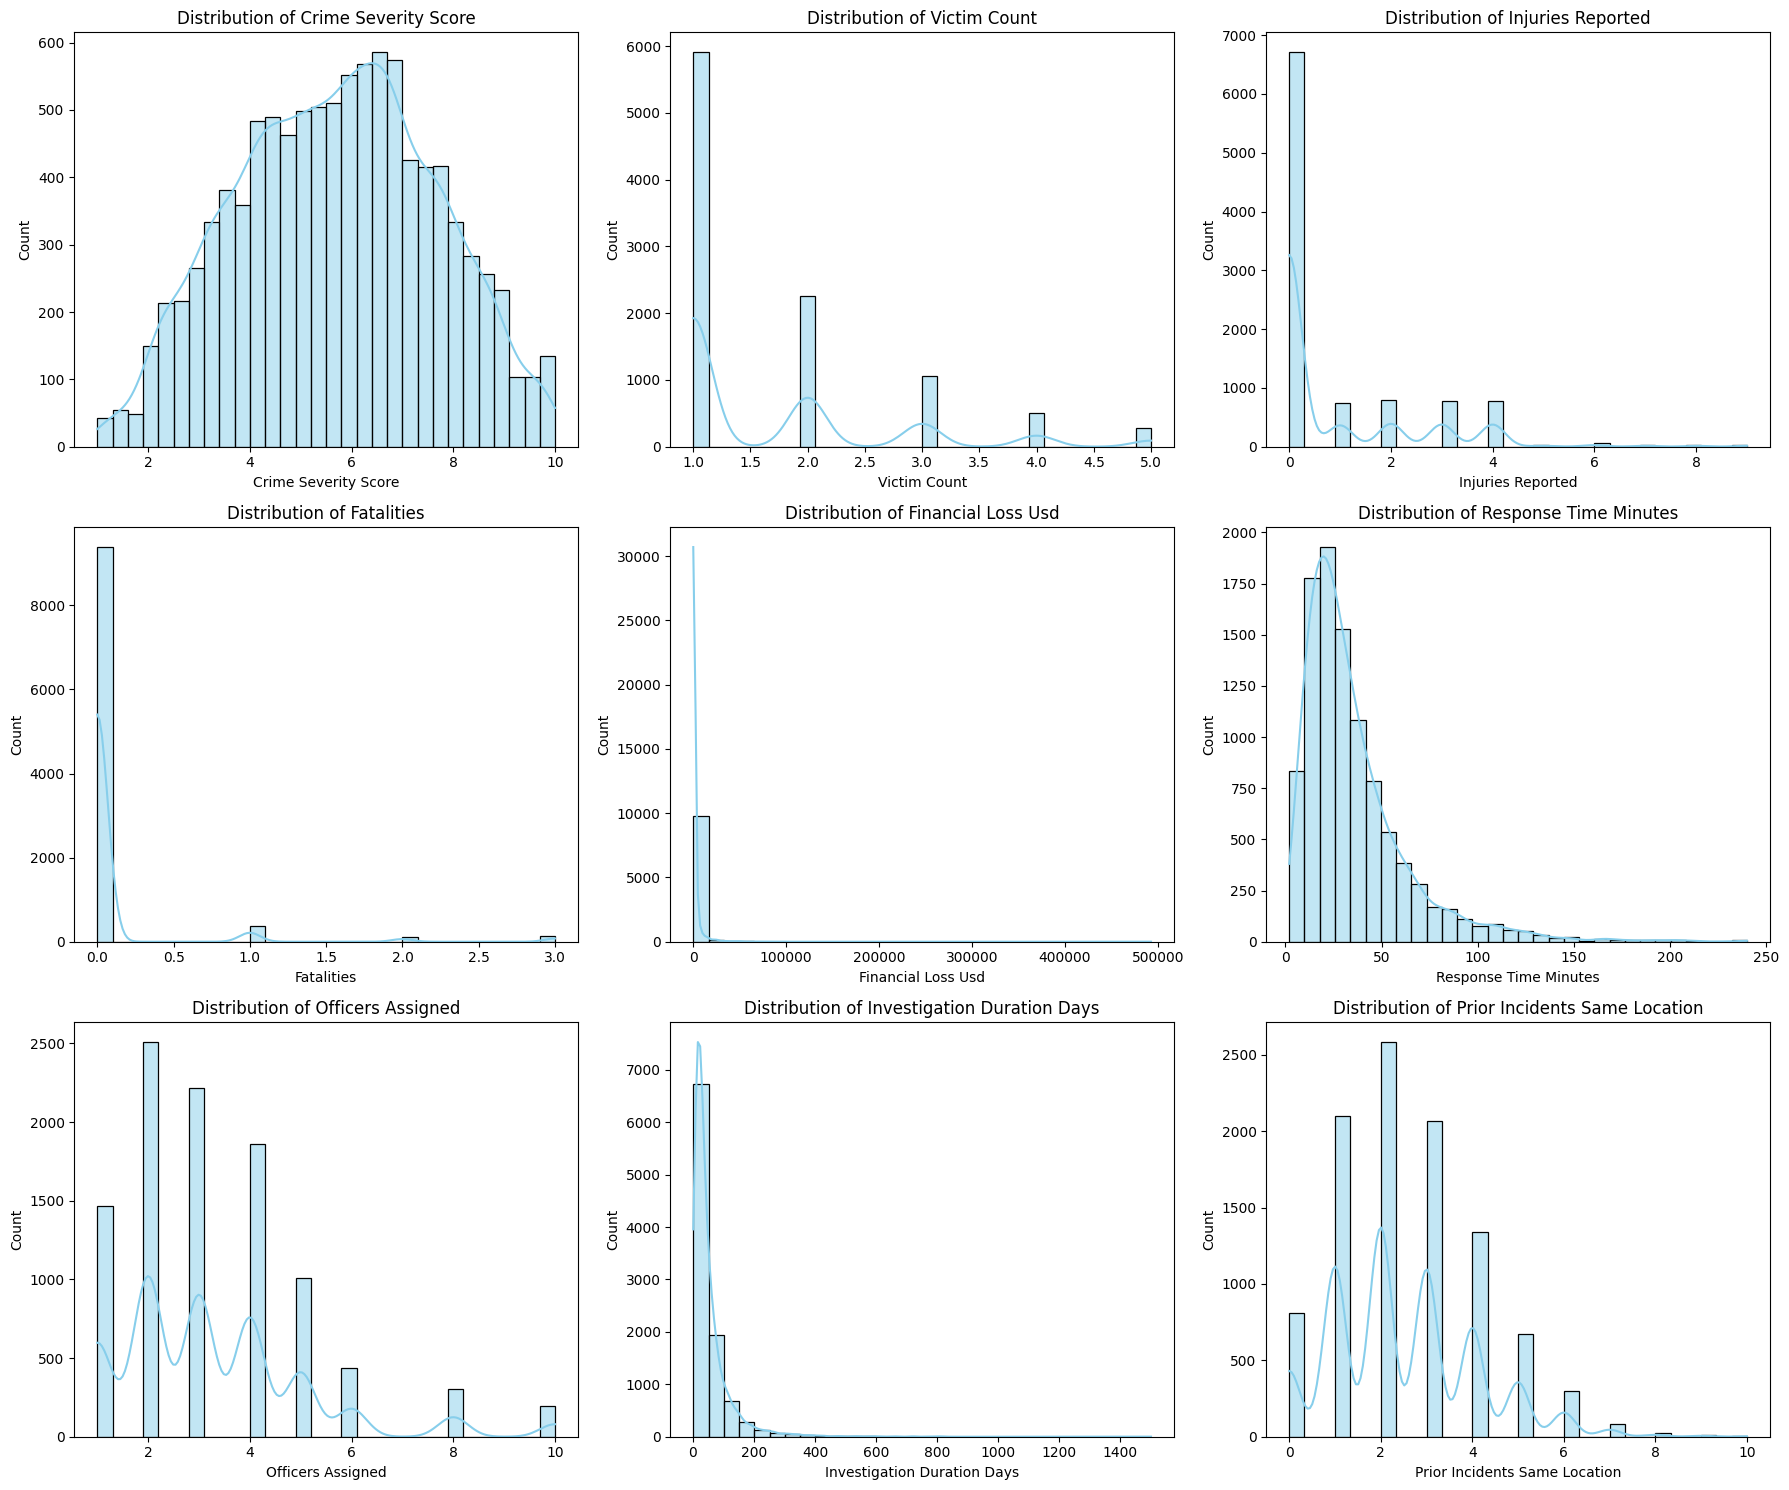

In [42]:
# Important Numerical Columns
num_cols = ['crime_severity_score', 'victim_count', 'injuries_reported', 
            'fatalities', 'financial_loss_usd', 'response_time_minutes',
            'officers_assigned', 'investigation_duration_days', 
            'prior_incidents_same_location', 'safety_index']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, col in enumerate(num_cols[:9]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

year: 0 outliers


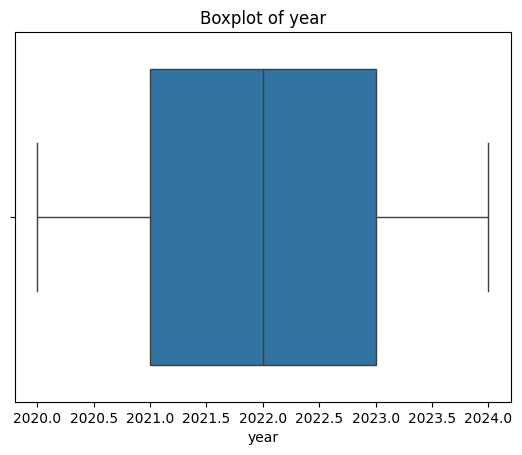

month: 0 outliers


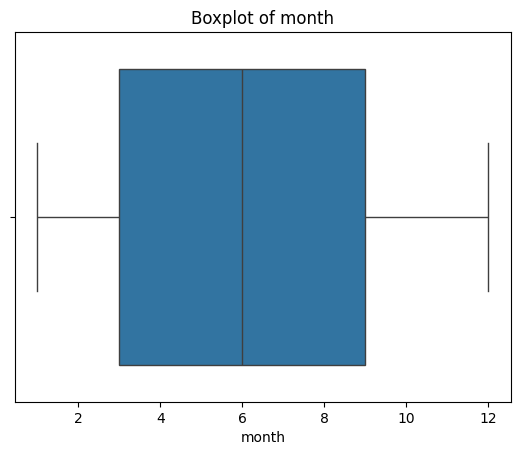

population_density_per_sqkm: 831 outliers


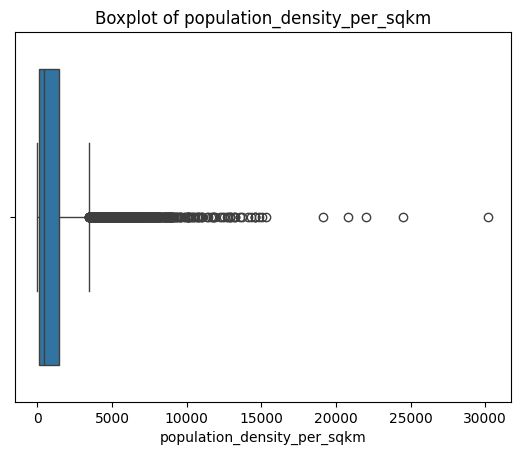

crime_severity_score: 0 outliers


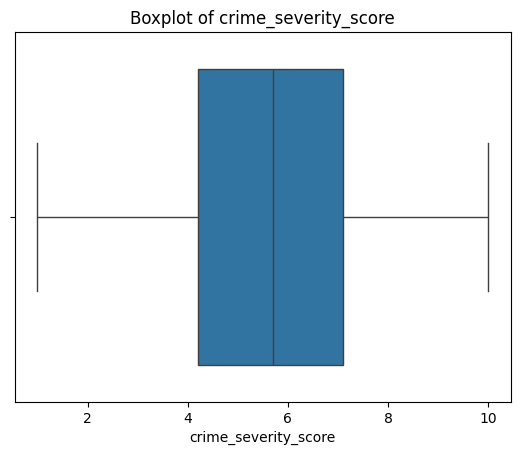

victim_count: 787 outliers


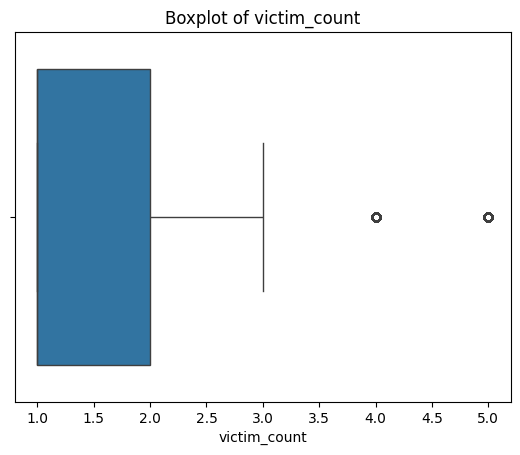

injuries_reported: 151 outliers


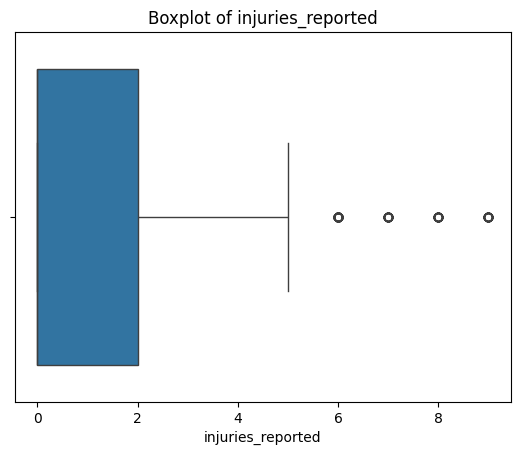

fatalities: 612 outliers


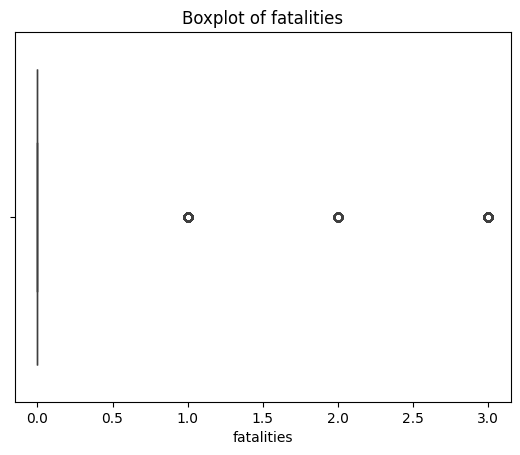

financial_loss_usd: 1407 outliers


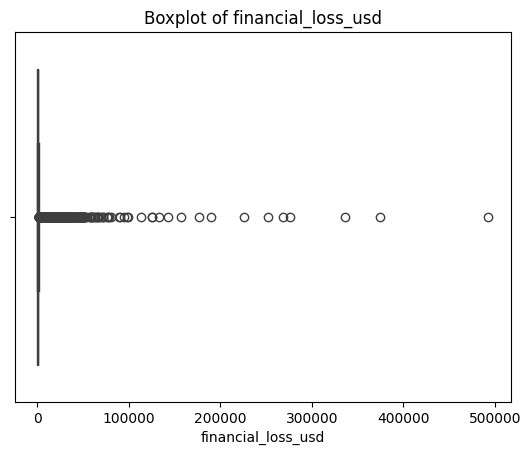

response_time_minutes: 596 outliers


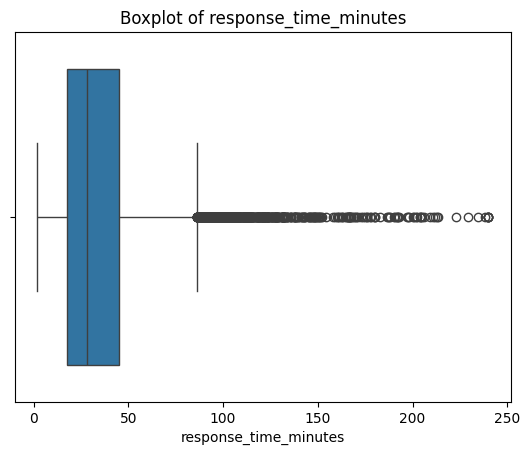

officers_assigned: 502 outliers


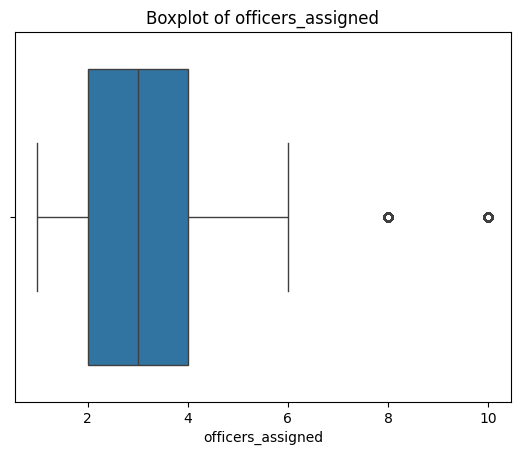

investigation_duration_days: 783 outliers


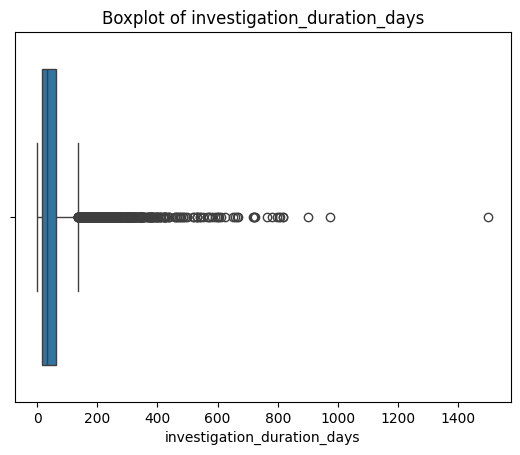

prior_incidents_same_location: 126 outliers


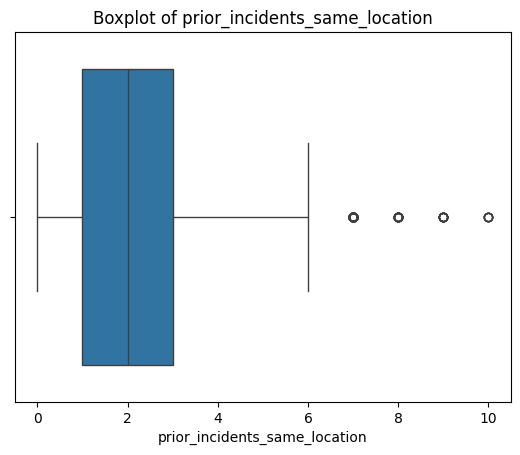

safety_index: 0 outliers


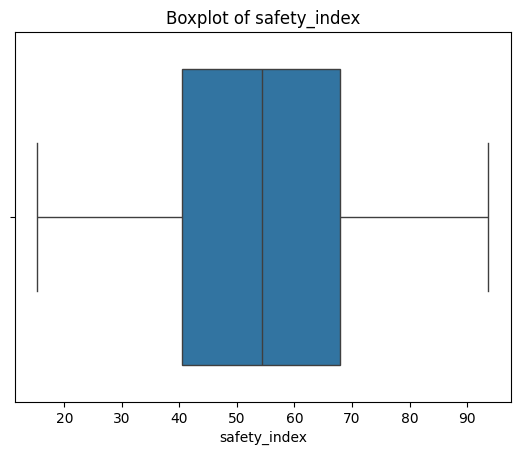

In [72]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

    print(f"{col}: {len(outliers)} outliers")

    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

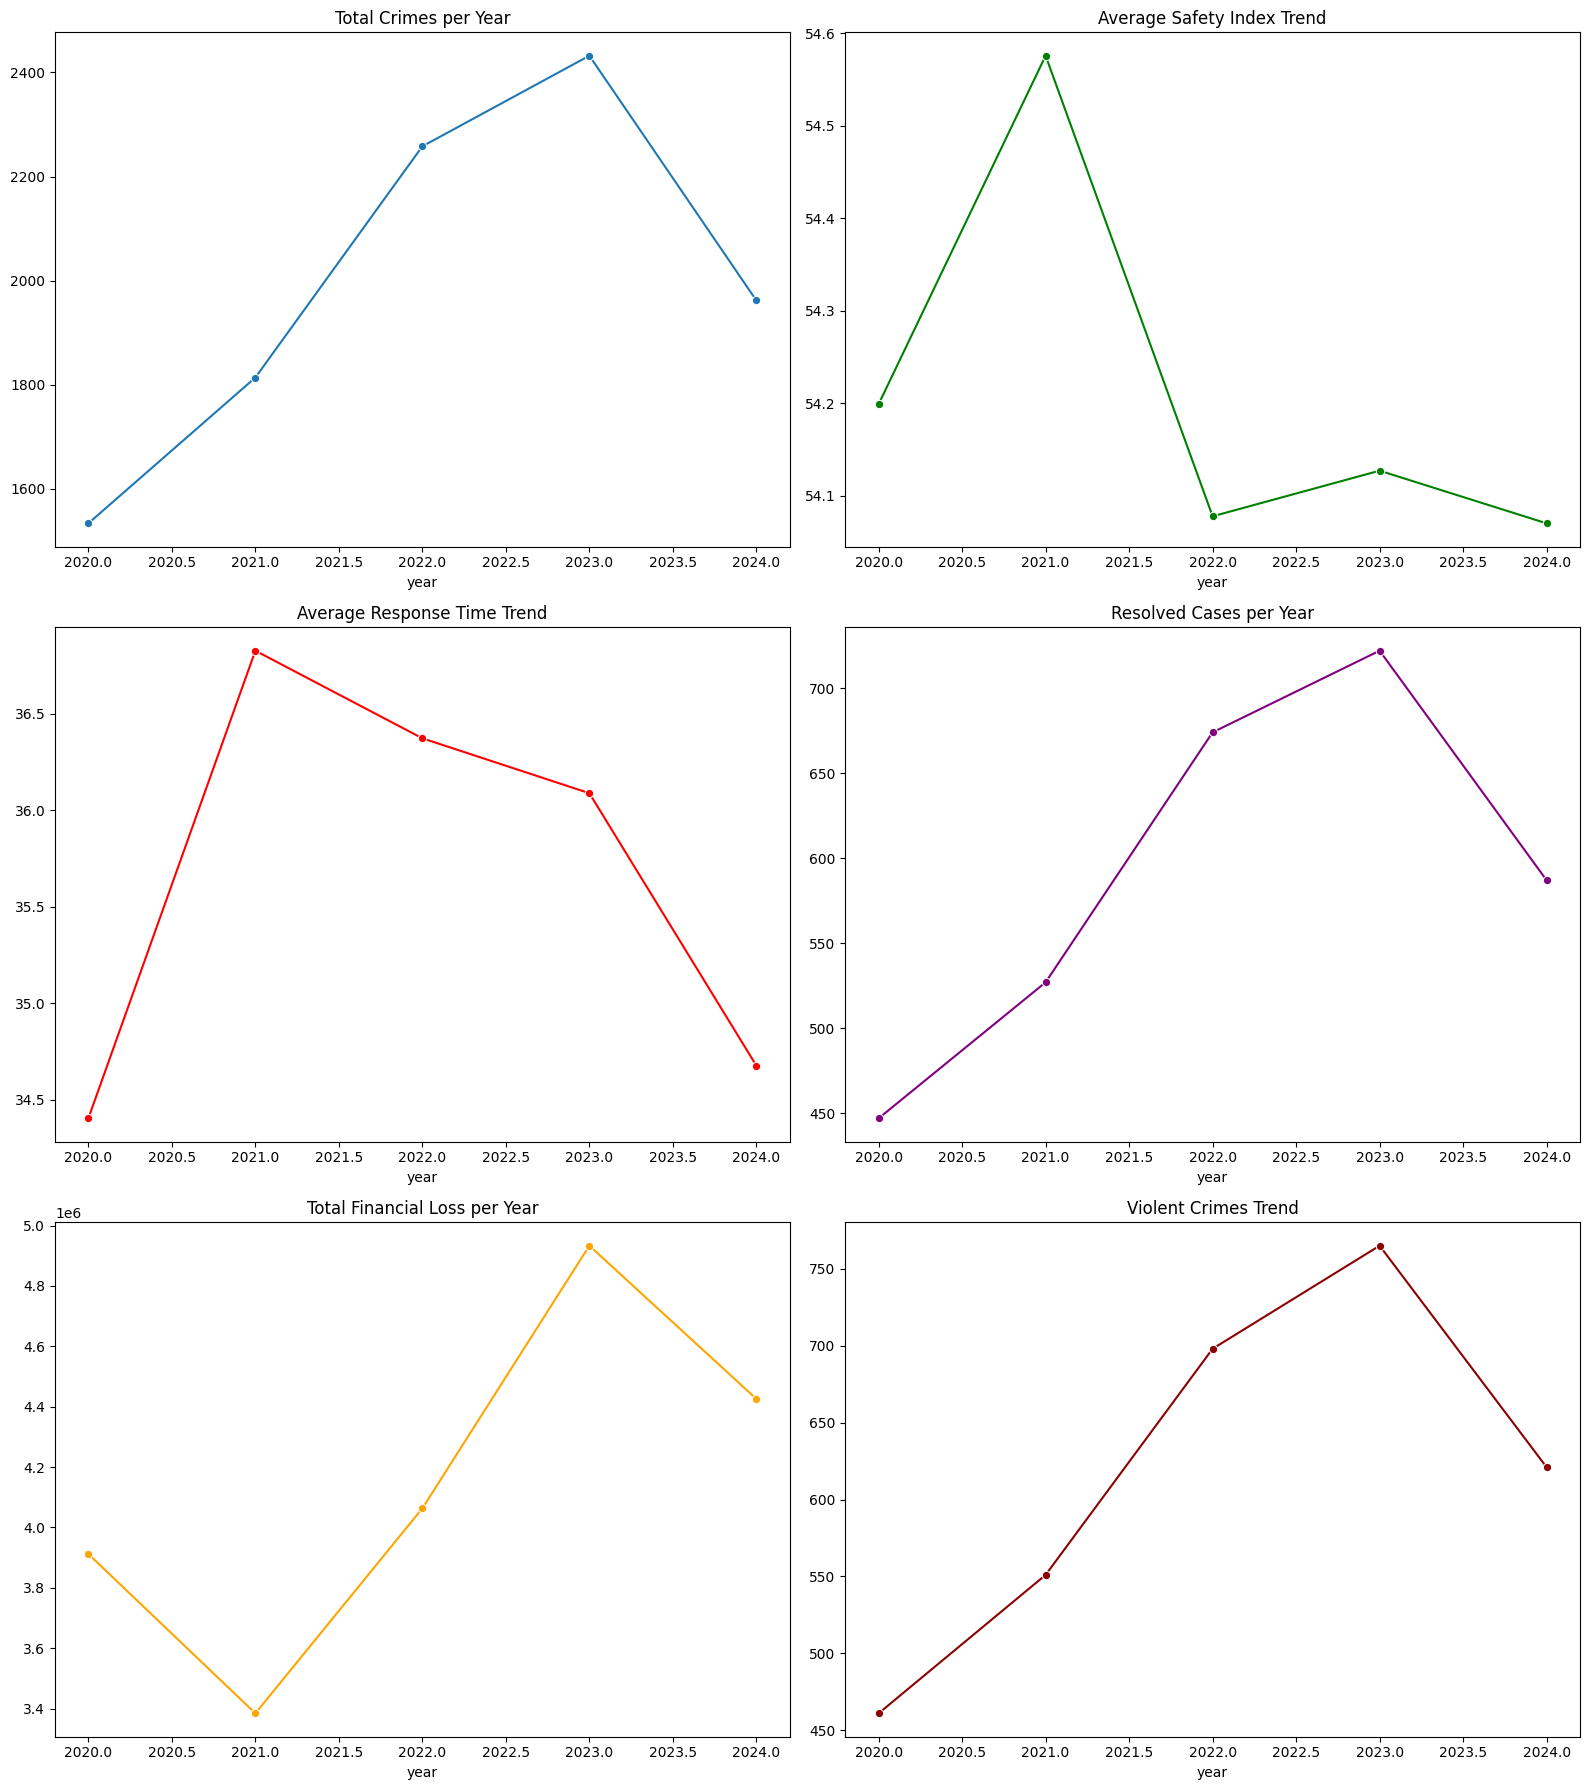

In [44]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.ravel()

# 1. Crime Trend by Year
yearly_crimes = df.groupby('year').size()
sns.lineplot(x=yearly_crimes.index, y=yearly_crimes.values, ax=axes[0], marker='o')
axes[0].set_title('Total Crimes per Year')

# 2. Average Safety Index by Year
safety_year = df.groupby('year')['safety_index'].mean()
sns.lineplot(x=safety_year.index, y=safety_year.values, ax=axes[1], marker='o', color='green')
axes[1].set_title('Average Safety Index Trend')

# 3. Response Time Trend
response_year = df.groupby('year')['response_time_minutes'].mean()
sns.lineplot(x=response_year.index, y=response_year.values, ax=axes[2], marker='o', color='red')
axes[2].set_title('Average Response Time Trend')

# 4. Resolved Crimes Trend
resolved_year = df[df['crime_resolved'] == 'Yes'].groupby('year').size()
sns.lineplot(x=resolved_year.index, y=resolved_year.values, ax=axes[3], marker='o', color='purple')
axes[3].set_title('Resolved Cases per Year')

# 5. Financial Loss Trend
loss_year = df.groupby('year')['financial_loss_usd'].sum()
sns.lineplot(x=loss_year.index, y=loss_year.values, ax=axes[4], marker='o', color='orange')
axes[4].set_title('Total Financial Loss per Year')

# 6. Violent Crimes Trend
violent = ['Murder', 'Assault', 'Robbery', 'Sexual Assault']
violent_df = df[df['crime_type'].isin(violent)].groupby('year').size()
sns.lineplot(x=violent_df.index, y=violent_df.values, ax=axes[5], marker='o', color='darkred')
axes[5].set_title('Violent Crimes Trend')

plt.tight_layout()
plt.show()

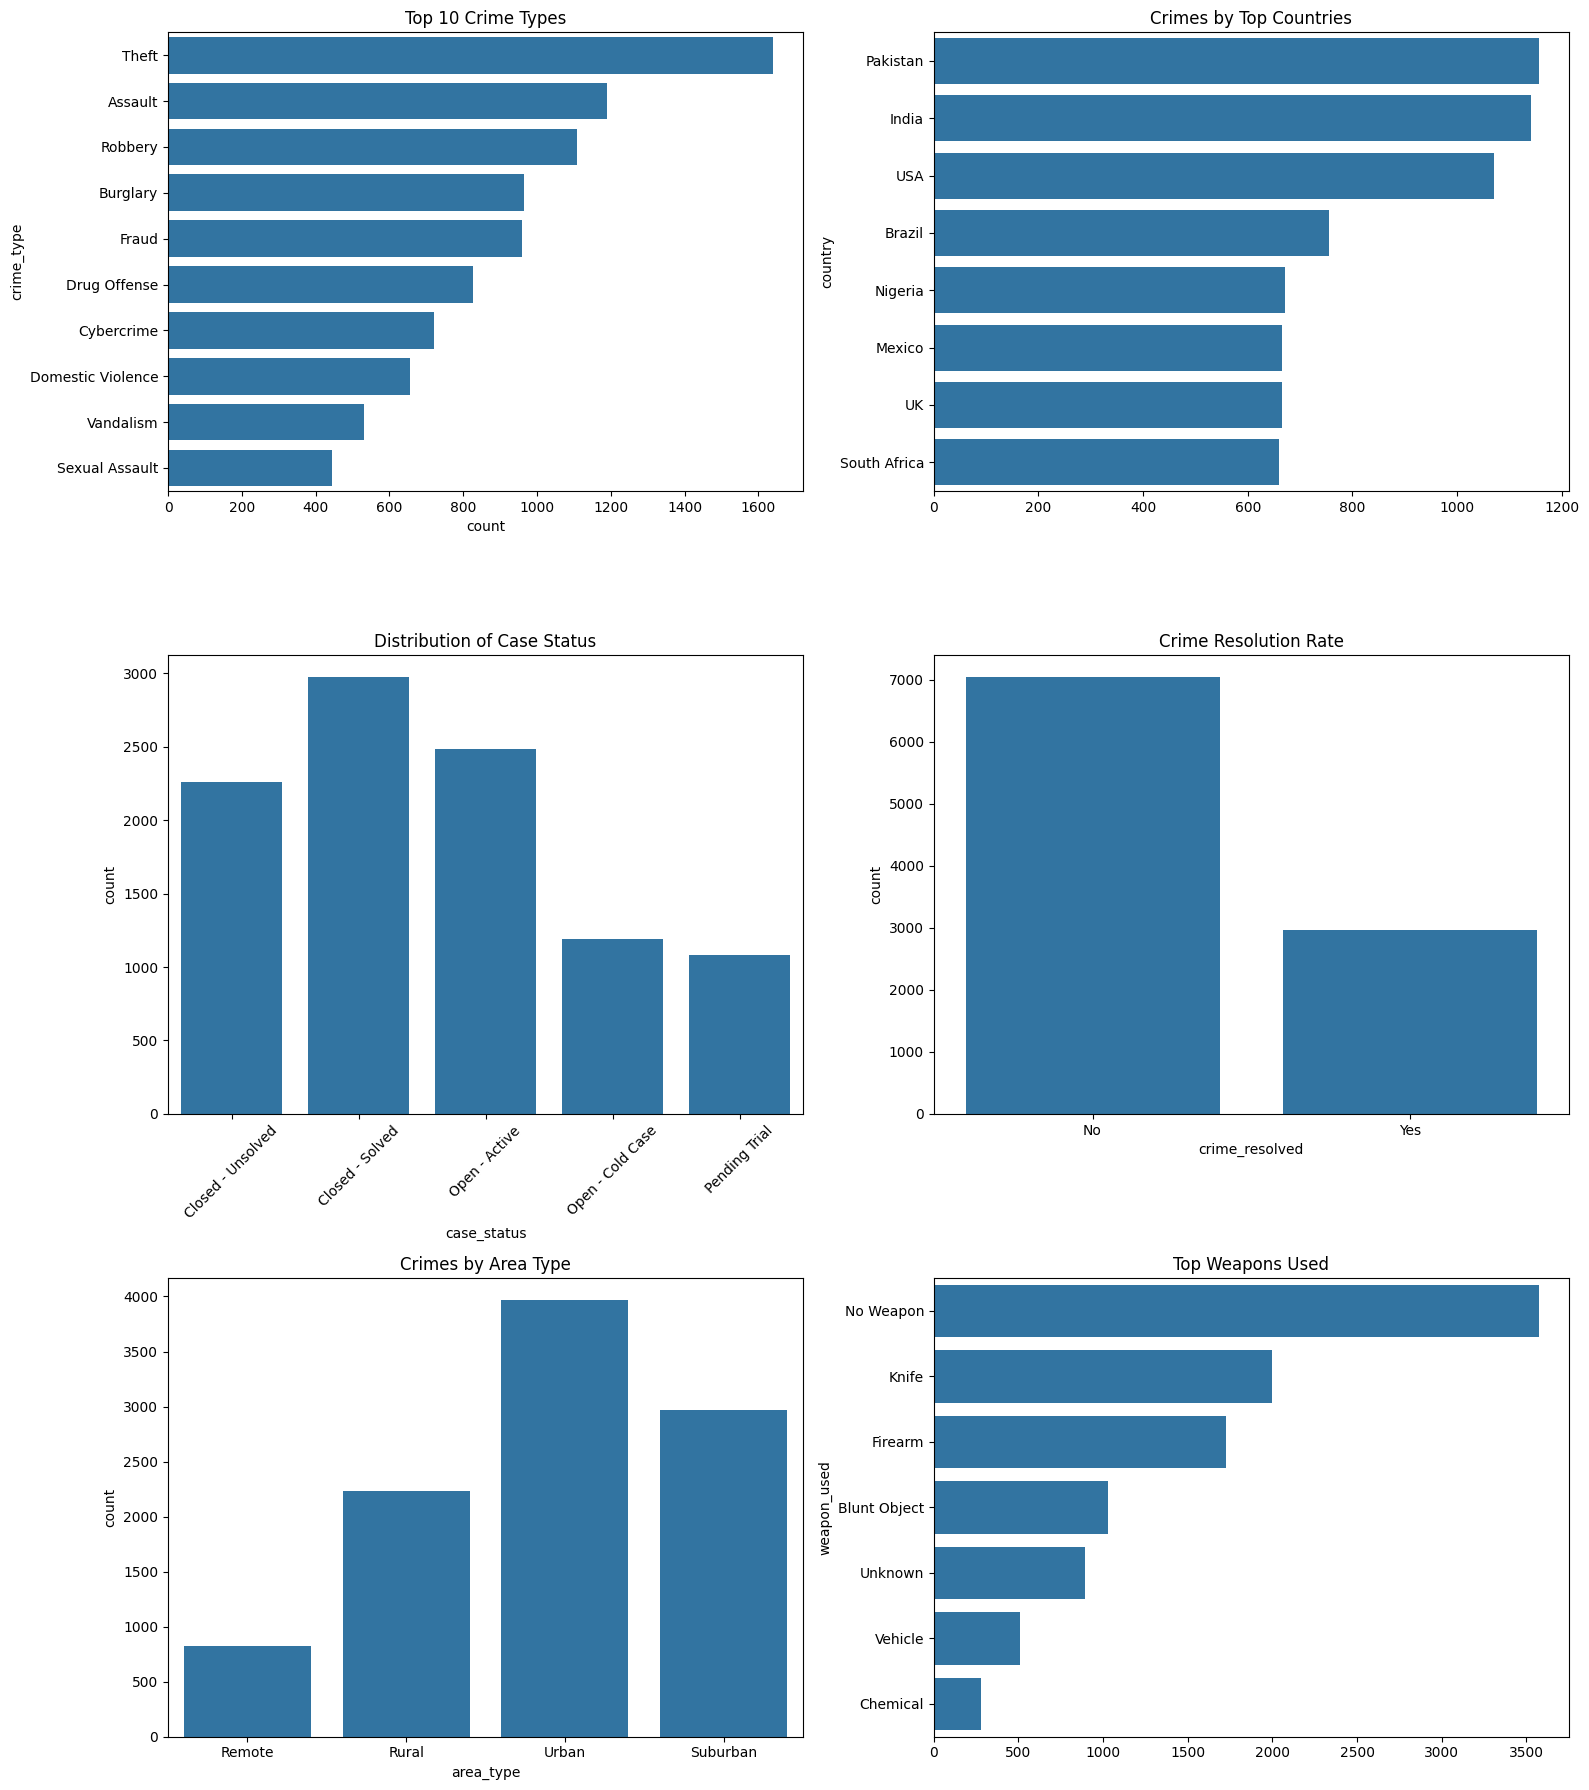

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.ravel()

# 1. Top Crime Types
sns.countplot(y='crime_type', data=df, order=df['crime_type'].value_counts().index[:10], ax=axes[0])
axes[0].set_title('Top 10 Crime Types')

# 2. Crimes by Country
top_countries = df['country'].value_counts().head(8)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1])
axes[1].set_title('Crimes by Top Countries')

# 3. Case Status
sns.countplot(x='case_status', data=df, ax=axes[2])
axes[2].set_title('Distribution of Case Status')
axes[2].tick_params(axis='x', rotation=45)

# 4. Crime Resolved
sns.countplot(x='crime_resolved', data=df, ax=axes[3])
axes[3].set_title('Crime Resolution Rate')

# 5. Area Type
sns.countplot(x='area_type', data=df, ax=axes[4])
axes[4].set_title('Crimes by Area Type')

# 6. Weapon Used
top_weapons = df['weapon_used'].value_counts().head(8)
sns.barplot(x=top_weapons.values, y=top_weapons.index, ax=axes[5])
axes[5].set_title('Top Weapons Used')

plt.tight_layout()
plt.show()

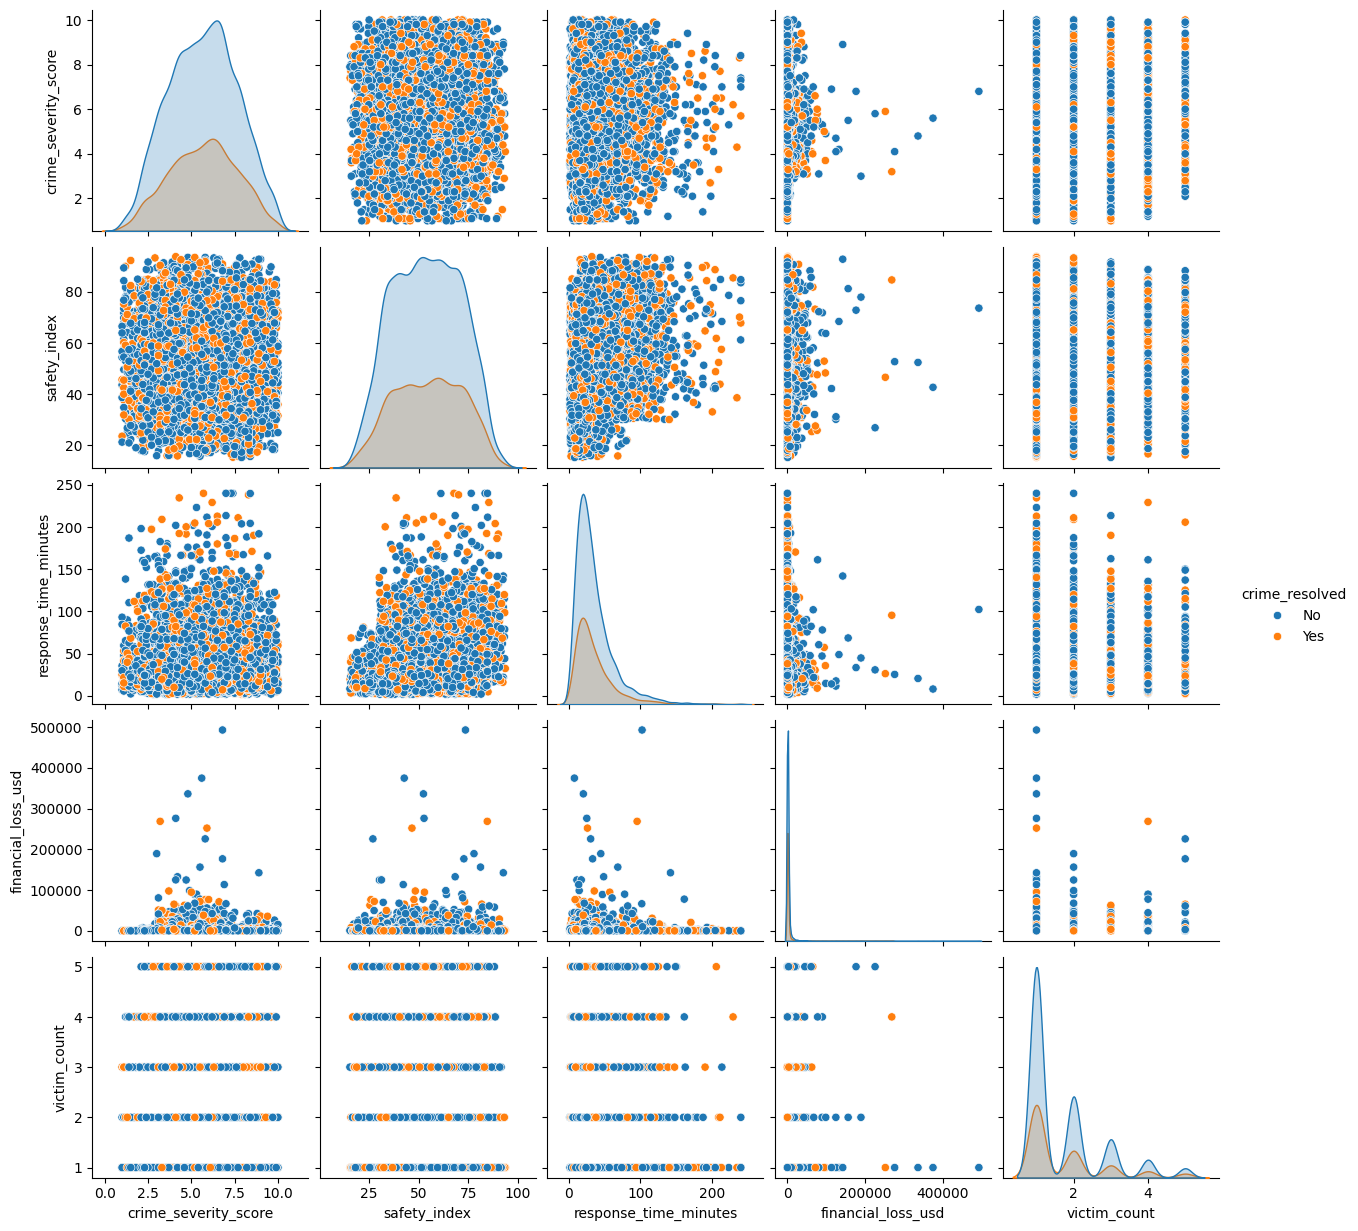

In [46]:
# Pairplot with target
target = 'crime_resolved'
sns.pairplot(df[['crime_severity_score', 'safety_index', 'response_time_minutes', 
                 'financial_loss_usd', 'victim_count', target]], 
             hue=target, diag_kind='kde')
plt.show()

In [57]:
# Bivariate analysis
# two categorical variables (crime_type vs crime_resolved)

# Create contingency table
table = pd.crosstab(df['crime_type'], df['crime_resolved'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("p-value:", p)

Chi-square value: 17.640847674162288
p-value: 0.2236311019601184


P value is > 0.05 so we accept the null hypothesis, This is indicate crime type and crime_resolved are independent each other

In [59]:
ResolvedCrime = df[df['crime_resolved'] == 'Yes']
Crime_counts = ResolvedCrime['crime_type'].value_counts()
Crime_percentage = (Crime_counts / Crime_counts.sum()) * 100
Crime_percentage

crime_type
Theft                16.097396
Robbery              12.478864
Assault              11.768684
Fraud                 9.908691
Burglary              9.164694
Drug Offense          8.251606
Cybercrime            7.642881
Domestic Violence     5.985796
Vandalism             4.903619
Sexual Assault        4.599256
Murder                3.111261
Arson                 1.893811
Extortion             1.792357
Kidnapping            1.420358
Trafficking           0.980724
Name: count, dtype: float64

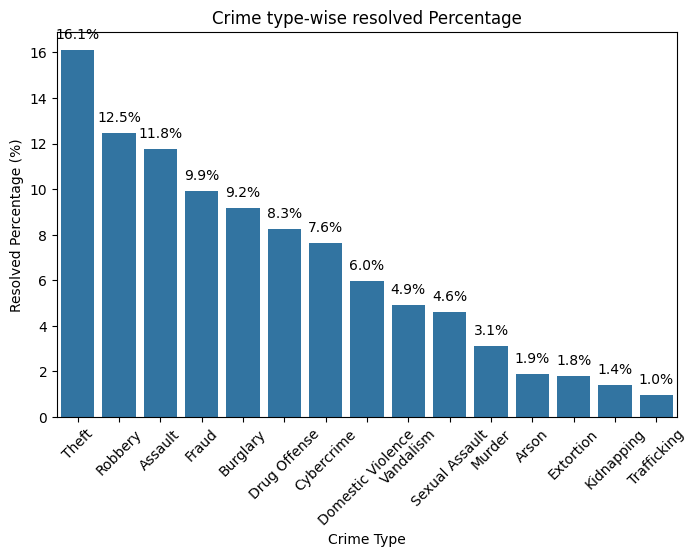

In [60]:
crime_summary = pd.DataFrame({
    'Count': Crime_counts,
    'Percentage': Crime_percentage
})

plt.figure(figsize=(8,5))
sns.barplot(x=crime_summary.index, y=crime_summary['Percentage'])

plt.title("Crime type-wise resolved Percentage")
plt.ylabel("Resolved Percentage (%)")
plt.xlabel("Crime Type")
plt.xticks(rotation=45)
for i, value in enumerate(crime_summary['Percentage']):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha='center')
plt.show()

In [61]:
#  two numerical varieble - Correlation
corr_saft_responsetime = df['safety_index'].corr(df['response_time_minutes'])
print("Correlation:", corr_saft_responsetime)

corr, p_value = stats.pearsonr(df['safety_index'],df['response_time_minutes'])
print(p_value)

Correlation: 0.16555651631476812
2.212533216639477e-62


P value is < 0.05 so we accept the null hypothesis, This is indicating that safty and response time are depended each other

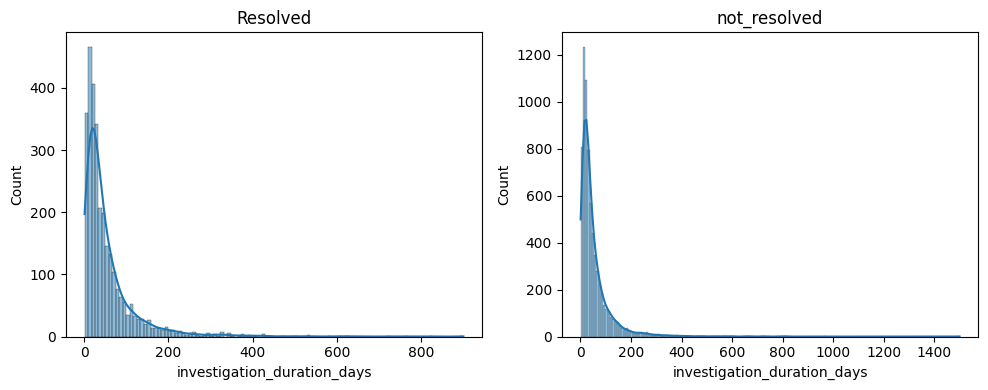

In [63]:
# numerical vs two group categorical variables - T-Test
# Normality test
Resolved= df[df['crime_resolved'] == "Yes"]['investigation_duration_days']
not_resolved = df[df['crime_resolved']== "No"]['investigation_duration_days']
plt.figure(figsize=(10,4))

# First histogram
plt.subplot(1, 2, 1)
sns.histplot(Resolved, kde=True)
plt.title("Resolved")

# Second histogram
plt.subplot(1, 2, 2)
sns.histplot(not_resolved, kde=True)
plt.title("not_resolved")

plt.tight_layout()
plt.show()

Two groupa are not normaly distributed by beased on Central limit therom we can say two groups are normaly distributed

In [65]:
# Homogeneity of Variances Assumption
stats.levene(Resolved, not_resolved)

LeveneResult(statistic=np.float64(0.21856988926191065), pvalue=np.float64(0.6401419473530182))

p value is > 0.05, we accept ths null hypothesis, This is indicate two groups are equal

In [66]:
# Perfom T test

stats.ttest_ind(Resolved, not_resolved)

TtestResult(statistic=np.float64(0.30405463815120604), pvalue=np.float64(0.7610925927656392), df=np.float64(9998.0))

P value > 0.05, we accept null hypothesis, This is indicate two groups means are equal so both varibles are independent each other

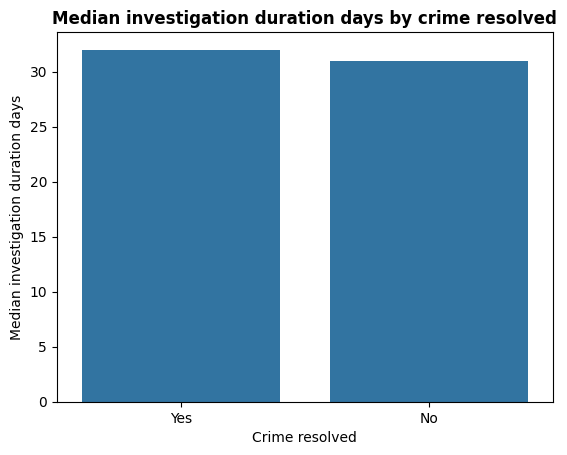

In [68]:
investigate_days_score = df.groupby('crime_resolved')['investigation_duration_days'].median().sort_values(ascending=False)

sns.barplot(x=investigate_days_score.index, y=investigate_days_score.values)

plt.title('Median investigation duration days by crime resolved', fontweight='bold')
plt.xlabel('Crime resolved')
plt.ylabel('Median investigation duration days')

plt.show()

In [69]:
# numerical vs three or more groups categorical variables - Anova test -  safety_index vs cctv_coverage
# Get unique industries
cctv = df['cctv_coverage'].unique()

# Create salary groups for each industry
groups = [df[df['cctv_coverage'] == ind]['safety_index'] for ind in cctv]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3.0423981755368734
p-value: 0.047764497067004905


P value < 0.05, we reject null hypothesis, This is indicate all groups means are not equal so both varibles are dependent each other

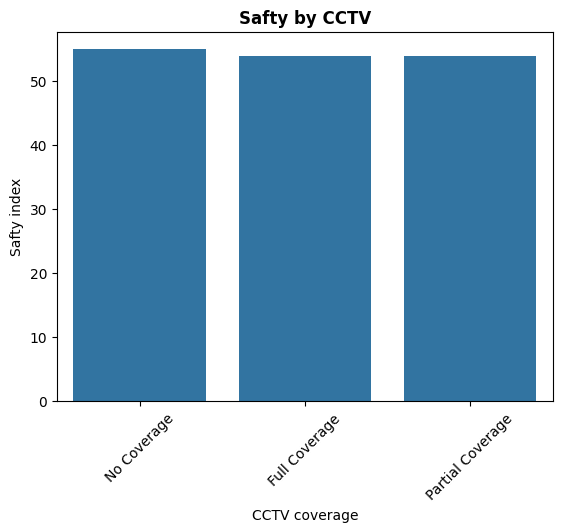

In [70]:
cctv_safty = df.groupby('cctv_coverage')['safety_index'].mean().sort_values(ascending=False)

# Create bar chart
sns.barplot(x=cctv_safty.index, y=cctv_safty.values)

# Formatting
plt.title('Safty by CCTV', fontweight='bold')
plt.xlabel('CCTV coverage')
plt.ylabel('Safty index')
plt.xticks(rotation=45)

plt.show()